In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torch.utils.data as data
from torch.utils.data import Subset
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from models.position_embedding import SinusoidalPositionEmbeddings
from models.unet import UNet
from utils import check_posterior_logic, verify_training_inputs, check_noise_correlation, visualise_loader, make_beta_schedule, periodic_sample_grids, ancestral_sample, plot_ancestral_samples, plot_sampling_norms
from diffusion.diffusion import DiffusionProcess

In [4]:
EPOCHS = 50
L = 1000
BATCH = 128

device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Device: {device}")

Device: cuda


In [5]:
# Loading MNIST dataset
# Convert to tensor and normalize between -1 and 1
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = data.DataLoader(train_dataset, batch_size=BATCH, shuffle=True, num_workers=4)

test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
test_loader = data.DataLoader(test_dataset, batch_size=BATCH, shuffle=False, num_workers=4)
    

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.54MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 146kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.38MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.07MB/s]


Min values per image: tensor(-1.)
Max values per image: tensor(1.)
Shape: torch.Size([128, 1, 28, 28])


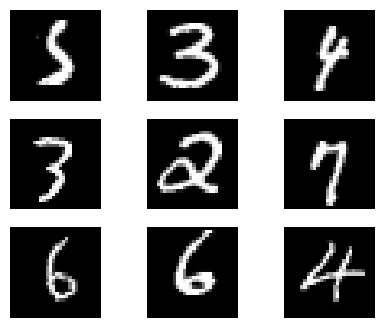

In [6]:
imgs, _ = next(iter(train_loader))

min_per_img = min(imgs.view(imgs.size(0), -1).min(dim=1).values)
max_per_img = max(imgs.view(imgs.size(0), -1).max(dim=1).values)
print("Min values per image:", min_per_img)
print("Max values per image:", max_per_img)

print(f"Shape: {imgs.shape}")

visualise_loader(imgs, 9)

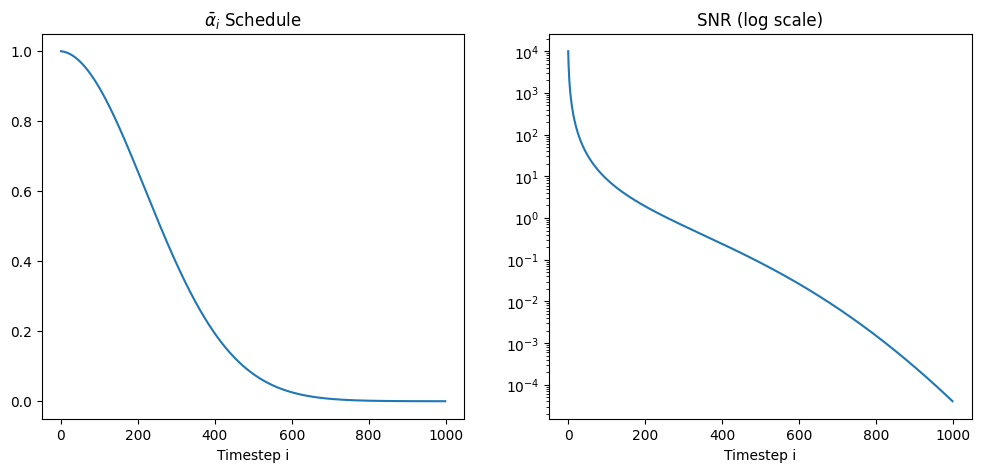

In [7]:
diff = DiffusionProcess(L=1000, device=device)
alphas_bar = diff.alphas_cumprod.to("cpu").numpy()
snr = alphas_bar / (1 - alphas_bar)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(alphas_bar)
plt.title(r"$\bar{\alpha}_i$ Schedule")
plt.xlabel("Timestep i")

plt.subplot(1, 2, 2)
plt.plot(snr)
plt.yscale('log')
plt.title("SNR (log scale)")
plt.xlabel("Timestep i")
plt.show()

In [8]:
x0 = imgs[0:1]
x0 = x0.to(device)
i = torch.tensor([500]).to(device)

samples = []
for _ in range(1000):
    xi = diff.q_sample(x0, i)
    samples.append(xi)

samples = torch.cat(samples, dim=0) # [1000, 1, 28, 28]

emp_mean = samples.mean().item()
emp_var = samples.var().item()

theo_mean = (diff.extract(diff.sqrt_alphas_cumprod, i, x0.shape) * x0).mean().item()
theo_var = (1 - diff.alphas_cumprod[i]).item()

print(f"Empirical Mean: {emp_mean:.4f} | Theoretical: {theo_mean:.4f}")
print(f"Empirical Var:  {emp_var:.4f} | Theoretical: {theo_var:.4f}")

Empirical Mean: -0.2176 | Theoretical: -0.2189
Empirical Var:  0.9471 | Theoretical: 0.9222


In [9]:
# Check for i >= 2 (index 1 in 0-based indexing)
beta_i = diff.betas[1:]
beta_tilde_i = diff.posterior_variance[1:]

print(f"All beta_tilde > 0: {torch.all(beta_tilde_i > 0).item()}")
print(f"All beta_tilde < beta: {torch.all(beta_tilde_i < beta_i).item()}")

All beta_tilde > 0: True
All beta_tilde < beta: True


In [10]:
x0 = imgs[0:1].to(device)
t = torch.tensor([50]).to(device)
eps = torch.randn_like(x0, device=device)
xi = diff.q_sample(x0, t, eps)

# theoretical posterior mean
mu_tilde, _ = diff.q_posterior_mean_var(x0, xi, t)

# predicted mean from perfect epsilon
mu_p = diff.p_mean_from_eps(xi, t, eps)

diff_val = torch.abs(mu_tilde - mu_p).max().item()
print(f"Max difference between posterior mean and p_mean: {diff_val:.6f}")

Max difference between posterior mean and p_mean: 0.000001


In [11]:
model = UNet()
optimizer = optim.Adam(model.parameters(), lr=2e-4)
criterion = nn.MSELoss()

overfit_model = UNet()
overfit_optimizer = optim.Adam(overfit_model.parameters(), lr=2e-4)
overfit_criterion = nn.MSELoss()

# Overfit test

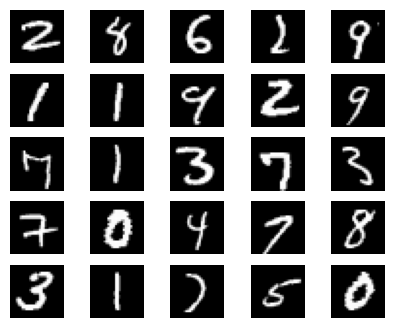

In [12]:
overfit_indices = list(range(256))
overfit_set = Subset(train_dataset, overfit_indices)
overfit_loader = torch.utils.data.DataLoader(overfit_set, batch_size=32, shuffle=True)

imgs, _ = next(iter(overfit_loader))
visualise_loader(imgs, 25, 5)

In [13]:
overfit_model.train()
overfit_model.to(device)
for epoch in tqdm(range(500)):
    for img, _ in overfit_loader:
        img = img.to(device)
        t = diff.sample_timesteps(img.shape[0]).to(device)
        eps = torch.randn_like(img, device=device)
        
        xi = diff.q_sample(img, t, eps)
        eps_hat = overfit_model(xi, t)
        
        loss = overfit_criterion(eps_hat, eps)
        
        overfit_optimizer.zero_grad()
        loss.backward()
        overfit_optimizer.step()

torch.save(overfit_model.state_dict(), "overfit_model_weights.pth")
print("Model saved successfully!")

100%|██████████| 500/500 [01:06<00:00,  7.54it/s]

Model saved successfully!


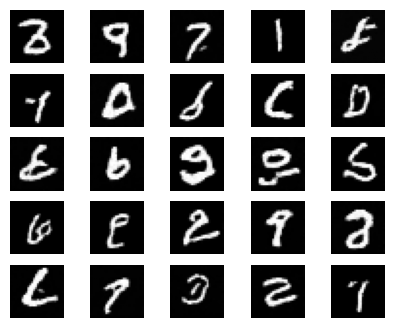

In [14]:
periodic_sample_grids(overfit_model, diff, 25, device, 5)

# Sanity Checks

Distance at i=100: 0.1080
Distance at i-1: 0.1061


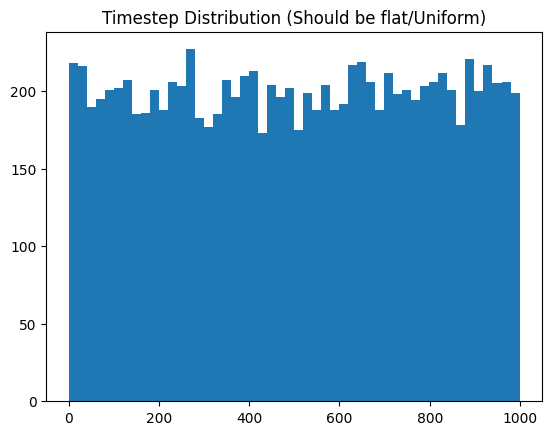

In [15]:
check_posterior_logic(diff, train_loader, device)
verify_training_inputs(diff)

  0%|          | 0/50 [00:00<?, ?it/s]


Epoch 1 | Loss = 17.3421531599015 | Grad Norm: 0.1886 | Noise Corr: 0.9855


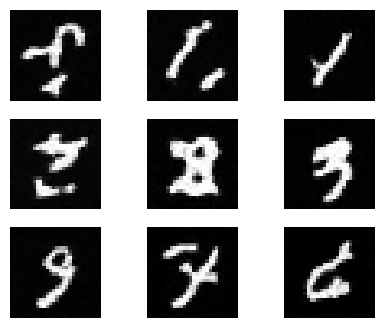

 10%|█         | 5/50 [01:01<09:01, 12.04s/it]


Epoch 6 | Loss = 13.17697248980403 | Grad Norm: 0.1167 | Noise Corr: 0.9881


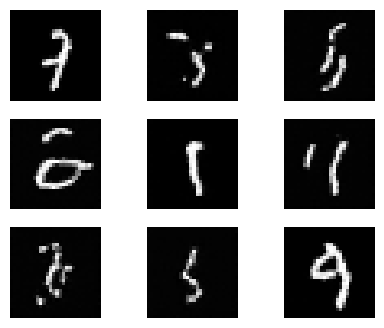

 20%|██        | 10/50 [02:04<08:04, 12.12s/it]


Epoch 11 | Loss = 12.030683176591992 | Grad Norm: 0.1019 | Noise Corr: 0.9873


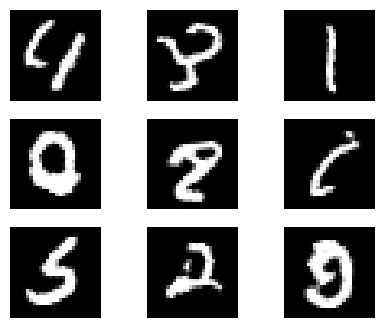

 30%|███       | 15/50 [03:06<07:03, 12.10s/it]


Epoch 16 | Loss = 11.648053860291839 | Grad Norm: 0.0672 | Noise Corr: 0.9855


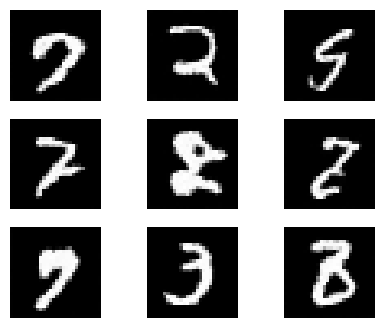

 40%|████      | 20/50 [04:09<06:07, 12.24s/it]


Epoch 21 | Loss = 11.230432329699397 | Grad Norm: 0.1566 | Noise Corr: 0.9878


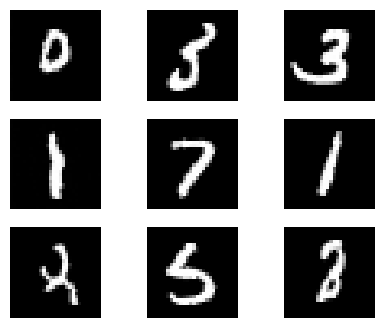

 50%|█████     | 25/50 [05:12<05:09, 12.37s/it]


Epoch 26 | Loss = 11.18998858705163 | Grad Norm: 0.1100 | Noise Corr: 0.9895


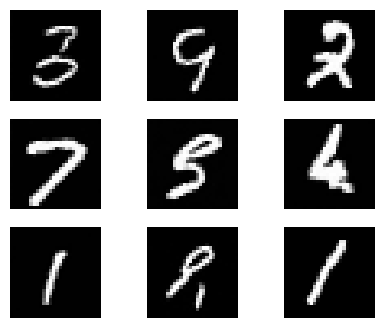

 60%|██████    | 30/50 [06:16<04:06, 12.32s/it]


Epoch 31 | Loss = 10.944561975076795 | Grad Norm: 0.0627 | Noise Corr: 0.9896


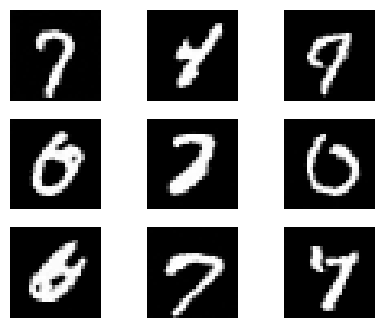

 70%|███████   | 35/50 [07:19<03:03, 12.23s/it]


Epoch 36 | Loss = 10.924847174435854 | Grad Norm: 0.1220 | Noise Corr: 0.9880


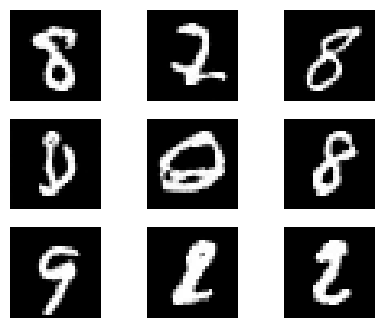

 80%|████████  | 40/50 [08:21<02:01, 12.14s/it]


Epoch 41 | Loss = 10.942241163924336 | Grad Norm: 0.0990 | Noise Corr: 0.9864


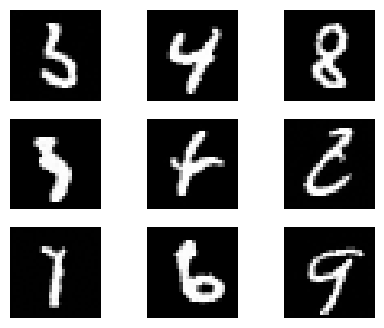

 90%|█████████ | 45/50 [09:24<01:01, 12.24s/it]


Epoch 46 | Loss = 10.674108281731606 | Grad Norm: 0.0529 | Noise Corr: 0.9905


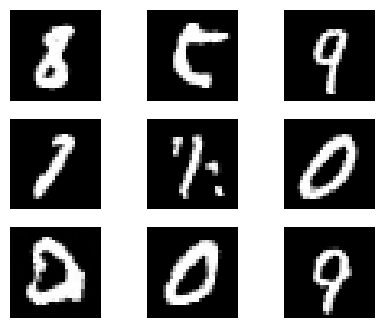

100%|██████████| 50/50 [10:28<00:00, 12.57s/it]

Model saved successfully!
Losses saved successfully!


In [17]:
losses = []
val_imgs, _ = next(iter(test_loader))
model.to(device)
for i in tqdm(range(EPOCHS)):
    acc_loss = 0
    for img, _ in train_loader:
        img = img.to(device)
        start = diff.sample_timesteps(img.shape[0]).to(device)
        eps = torch.randn_like(img, device=device)
        xi = diff.q_sample(img, start, eps)

        eps_hat = model(xi, start)

        loss = criterion(eps_hat, eps)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        acc_loss += loss.item()
    losses.append(acc_loss)

    if i % 5 == 0:
        total_norm = sum(p.grad.detach().data.norm(2).item() ** 2 for p in model.parameters() if p.grad is not None) ** 0.5
        corr = check_noise_correlation(model, diff, val_imgs.to(device))
        print(f"\nEpoch {i+1} | Loss = {acc_loss} | Grad Norm: {total_norm:.4f} | Noise Corr: {corr:.4f}")
        periodic_sample_grids(model, diff, 9, device)

torch.save(model.state_dict(), "lin_model_weights.pth")
print("Model saved successfully!")
np.save("lin_losses.npy", np.array(losses))
print("Losses saved successfully!")

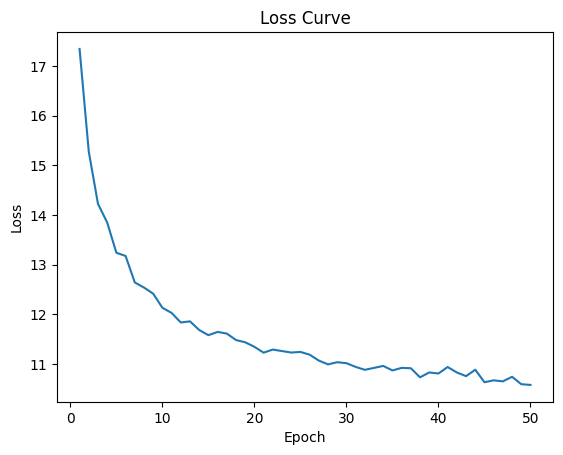

In [19]:
plt.title("Loss Curve")
plt.plot(np.arange(1,EPOCHS+1), losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# Full Ancestral DDPM

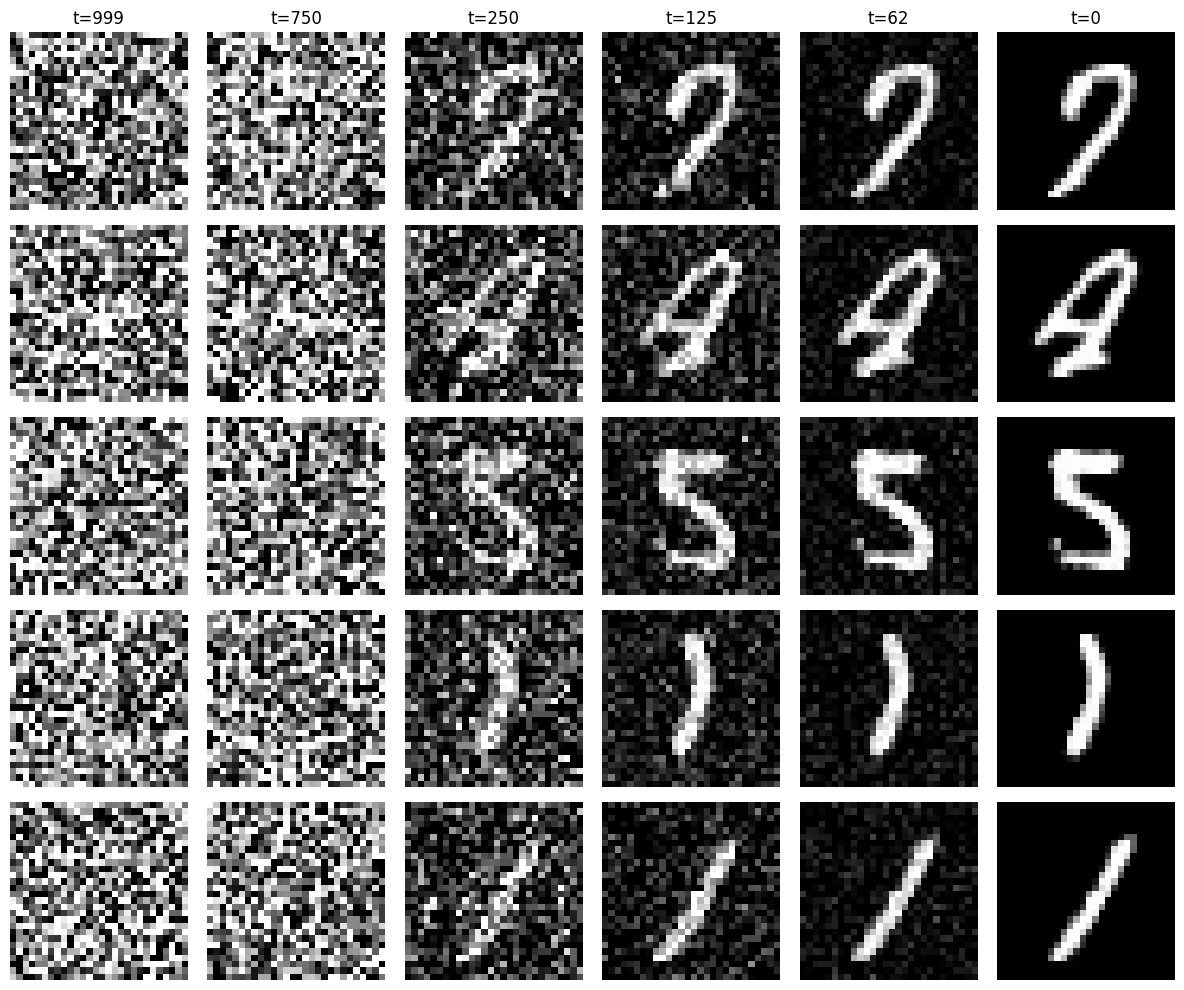

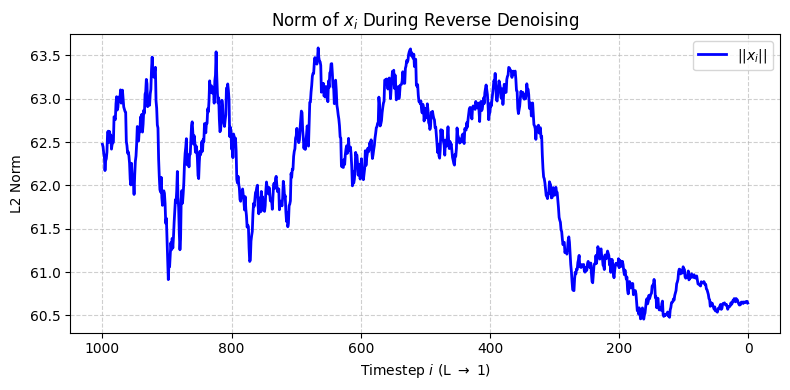

In [20]:
final_xi, intermediates, norms = ancestral_sample(model, diff, count=5, device=device)
plot_ancestral_samples(intermediates, count=5)
plot_sampling_norms(norms, L=diff.L)